In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
# https://www.kaggle.com/datasets/tamber/steam-video-games
dataset = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/Recommendation_systems/steam-200k.csv',
    header=None,
    names=['user-id', 'game-title', 'behavior-name', 'value', 'timestamp'],
)
dataset

,user-id,game-title,behavior-name,value,timestamp
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
...,...,...,...,...,...
199995,128470551,Titan Souls,play,1.5,0
199996,128470551,Grand Theft Auto Vice City,purchase,1.0,0
199997,128470551,Grand Theft Auto Vice City,play,1.5,0
199998,128470551,RUSH,purchase,1.0,0


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from scipy.sparse import csr_matrix
import seaborn as sns

Статистика нормализованных оценок:
count    70489.000000
mean         0.790068
std          1.029283
min          0.000423
25%          0.075665
50%          0.338129
75%          1.047619
max          3.796712
Name: normalized_rating, dtype: float64

Всего пользователей: 11350
Всего игр: 3600
Размерность матрицы взаимодействий: (11350, 3600)
Заполненность матрицы: 0.1725%


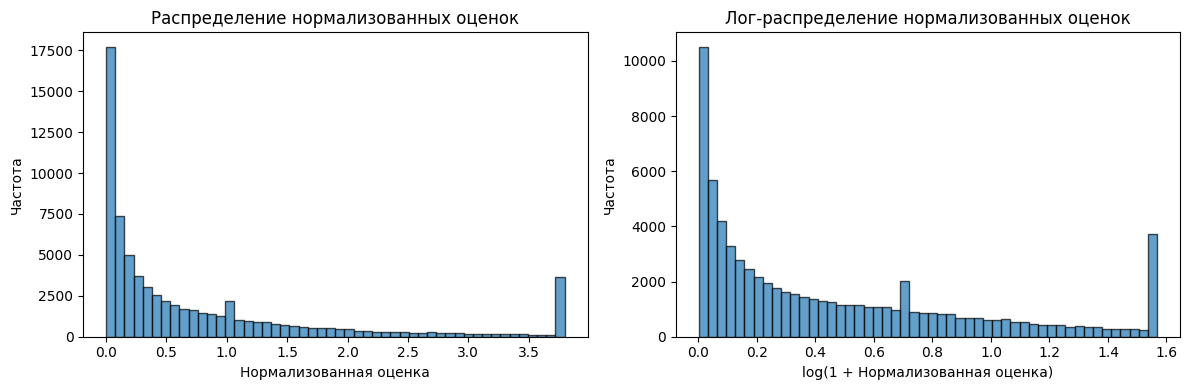

In [6]:
# Фильтруем только игровые сессии
play_dataset = dataset[dataset['behavior-name'] == 'play'].copy()

# Вычисляем среднее время игры для каждой игры
game_avg_playtime = play_dataset.groupby('game-title')['value'].mean().reset_index()
game_avg_playtime.columns = ['game-title', 'avg_playtime']

# Объединяем с исходными данными
play_dataset = play_dataset.merge(game_avg_playtime, on='game-title')

# Вычисляем нормализованную оценку
play_dataset['normalized_rating'] = play_dataset['value'] / play_dataset['avg_playtime']

# Ограничиваем экстремальные значения (обрезка на 95 перцентиле)
rating_95p = play_dataset['normalized_rating'].quantile(0.95)
play_dataset['normalized_rating'] = np.where(
    play_dataset['normalized_rating'] > rating_95p,
    rating_95p,
    play_dataset['normalized_rating']
)

print("Статистика нормализованных оценок:")
print(play_dataset['normalized_rating'].describe())

# Создаем матрицу пользователь-игра
user_ids = play_dataset['user-id'].unique()
game_titles = play_dataset['game-title'].unique()

user_to_index = {user: idx for idx, user in enumerate(user_ids)}
game_to_index = {game: idx for idx, game in enumerate(game_titles)}

print(f"\nВсего пользователей: {len(user_ids)}")
print(f"Всего игр: {len(game_titles)}")

# Создаем разреженную матрицу
rows = play_dataset['user-id'].map(user_to_index)
cols = play_dataset['game-title'].map(game_to_index)
values = play_dataset['normalized_rating']

interaction_matrix = csr_matrix((values, (rows, cols)),
                               shape=(len(user_ids), len(game_titles)))

print(f"Размерность матрицы взаимодействий: {interaction_matrix.shape}")
print(f"Заполненность матрицы: {interaction_matrix.nnz / (interaction_matrix.shape[0] * interaction_matrix.shape[1]) * 100:.4f}%")

# Визуализация распределения нормализованных оценок
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(play_dataset['normalized_rating'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение нормализованных оценок')
plt.xlabel('Нормализованная оценка')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
# Логарифмическая шкала для лучшей визуализации
plt.hist(np.log1p(play_dataset['normalized_rating']), bins=50, edgecolor='black', alpha=0.7)
plt.title('Лог-распределение нормализованных оценок')
plt.xlabel('log(1 + Нормализованная оценка)')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

In [8]:
class SVDRecommender:
    def __init__(self, n_components=50):
        self.n_components = n_components
        self.svd = None
        self.user_factors = None
        self.item_factors = None

    def fit(self, interaction_matrix):
        """Обучение SVD модели"""
        self.svd = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.user_factors = self.svd.fit_transform(interaction_matrix)
        self.item_factors = self.svd.components_.T

        # Объясненная дисперсия
        print(f"Объясненная дисперсия для {self.n_components} компонент: "
              f"{self.svd.explained_variance_ratio_.sum():.4f}")

        return self

    def predict(self, user_indices=None):
        """Предсказание оценок"""
        if user_indices is None:
            return self.user_factors @ self.item_factors.T
        else:
            return self.user_factors[user_indices] @ self.item_factors.T

    def calculate_rmse(self, true_matrix, predicted_matrix, mask=None):
        """Вычисление RMSE"""
        if mask is None:
            mask = (true_matrix != 0)

        diff = (true_matrix - predicted_matrix) * mask
        mse = np.sum(diff.data ** 2) / mask.nnz
        return np.sqrt(mse)

# Тестируем на одной конфигурации
test_recommender = SVDRecommender(n_components=20)
test_recommender.fit(interaction_matrix)
test_predictions = test_recommender.predict()

Объясненная дисперсия для 20 компонент: 0.2946


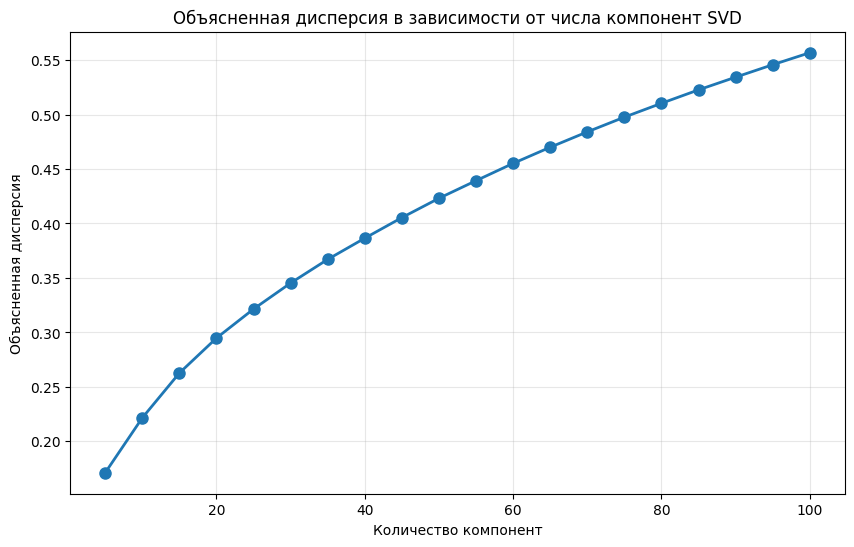

In [9]:
# Визуализация объясненной дисперсии для разных компонент
components_range = range(5, 101, 5)
explained_variances = []

for n_comp in components_range:
    svd_temp = TruncatedSVD(n_components=n_comp, random_state=42)
    svd_temp.fit(interaction_matrix)
    explained_variances.append(svd_temp.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 6))
plt.plot(components_range, explained_variances, marker='o', linewidth=2, markersize=8)
plt.xlabel('Количество компонент')
plt.ylabel('Объясненная дисперсия')
plt.title('Объясненная дисперсия в зависимости от числа компонент SVD')
plt.grid(True, alpha=0.3)
plt.show()

Оценка для n_components = 5
  Fold 1:
Объясненная дисперсия для 5 компонент: 0.1625
    RMSE = 1.2533
  Fold 2:
Объясненная дисперсия для 5 компонент: 0.1637
    RMSE = 1.2600
  Fold 3:
Объясненная дисперсия для 5 компонент: 0.1675
    RMSE = 1.2711
  Fold 4:
Объясненная дисперсия для 5 компонент: 0.1623
    RMSE = 1.2448
  Fold 5:
Объясненная дисперсия для 5 компонент: 0.1639
    RMSE = 1.2697
  Средний RMSE: 1.2598 ± 0.0099

Оценка для n_components = 10
  Fold 1:
Объясненная дисперсия для 10 компонент: 0.2119
    RMSE = 1.2490
  Fold 2:
Объясненная дисперсия для 10 компонент: 0.2128
    RMSE = 1.2555
  Fold 3:
Объясненная дисперсия для 10 компонент: 0.2161
    RMSE = 1.2666
  Fold 4:
Объясненная дисперсия для 10 компонент: 0.2120
    RMSE = 1.2424
  Fold 5:
Объясненная дисперсия для 10 компонент: 0.2127
    RMSE = 1.2704
  Средний RMSE: 1.2568 ± 0.0105

Оценка для n_components = 15
  Fold 1:
Объясненная дисперсия для 15 компонент: 0.2521
    RMSE = 1.2472
  Fold 2:
Объясненная диспер

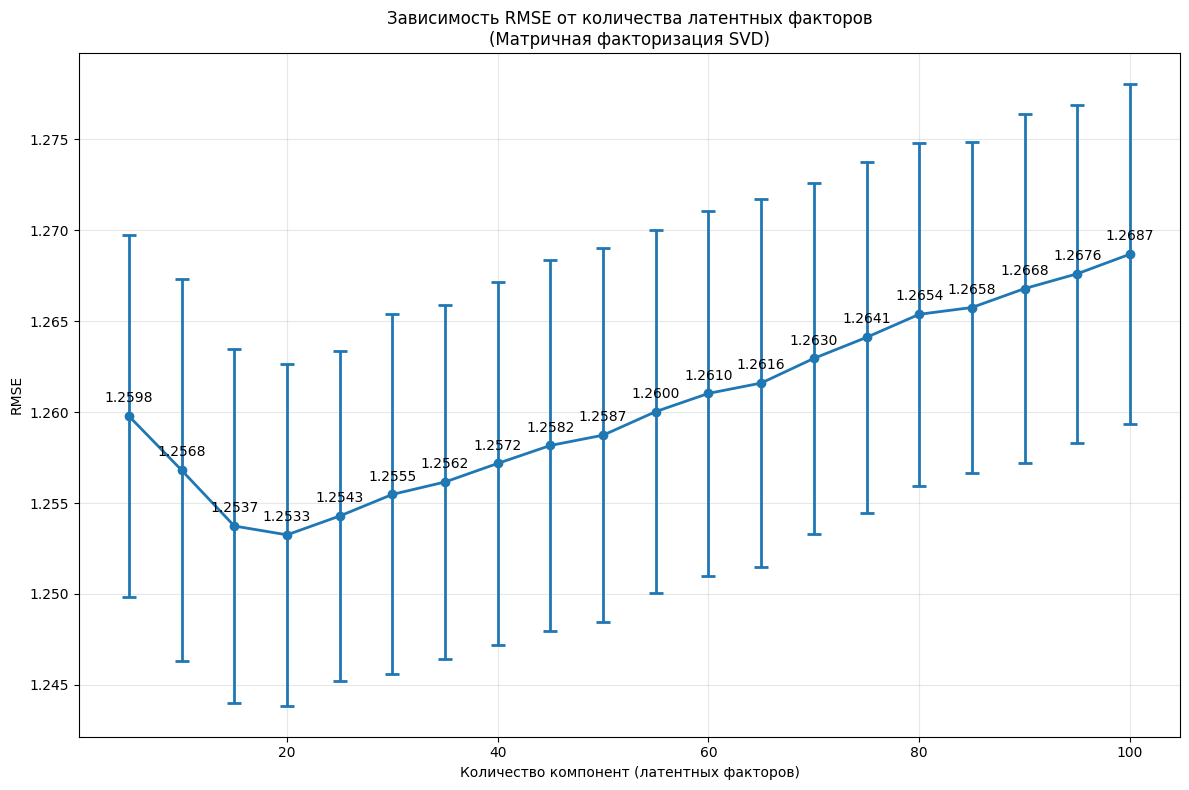

Лучшее количество компонент: 20


In [14]:
def evaluate_svd_parameters(interaction_matrix, n_components_list, n_folds=3):
    """Оценка параметров SVD с кросс-валидацией"""
    from sklearn.model_selection import KFold
    import numpy as np

    # Преобразуем разреженную матрицу в координатный формат для разделения
    coo_matrix = interaction_matrix.tocoo()
    user_indices = coo_matrix.row
    item_indices = coo_matrix.col
    ratings = coo_matrix.data

    results = {}

    for n_components in n_components_list:
        print(f"Оценка для n_components = {n_components}")
        fold_rmses = []

        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

        for fold, (train_idx, test_idx) in enumerate(kf.split(ratings)):
            print(f"  Fold {fold+1}:")

            # Создаем тренировочную матрицу
            train_rows = user_indices[train_idx]
            train_cols = item_indices[train_idx]
            train_data = ratings[train_idx]

            train_matrix = csr_matrix((train_data, (train_rows, train_cols)),
                                    shape=interaction_matrix.shape)

            # Создаем тестовую матрицу
            test_rows = user_indices[test_idx]
            test_cols = item_indices[test_idx]
            test_data = ratings[test_idx]

            # Обучаем модель на тренировочных данных
            recommender = SVDRecommender(n_components=n_components)
            recommender.fit(train_matrix)

            # Предсказываем оценки
            predictions = recommender.predict()

            # Вычисляем RMSE только на тестовых данных
            test_predictions = predictions[test_rows, test_cols]
            rmse = np.sqrt(np.mean((test_data - test_predictions) ** 2))

            fold_rmses.append(rmse)
            print(f"    RMSE = {rmse:.4f}")

        results[n_components] = {
            'mean_rmse': np.mean(fold_rmses),
            'std_rmse': np.std(fold_rmses),
            'all_rmses': fold_rmses
        }
        print(f"  Средний RMSE: {np.mean(fold_rmses):.4f} ± {np.std(fold_rmses):.4f}\n")

    return results

# Оценка различных параметров (возьмем меньше значений для скорости)
n_components_list = range(5, 101, 5)
results = evaluate_svd_parameters(interaction_matrix, n_components_list, n_folds=5)

# Визуализация результатов
mean_rmses = [results[n]['mean_rmse'] for n in n_components_list]
std_rmses = [results[n]['std_rmse'] for n in n_components_list]

plt.figure(figsize=(12, 8))
plt.errorbar(n_components_list, mean_rmses, yerr=std_rmses,
             marker='o', linewidth=2, capsize=5, capthick=2)
plt.xlabel('Количество компонент (латентных факторов)')
plt.ylabel('RMSE')
plt.title('Зависимость RMSE от количества латентных факторов\n(Матричная факторизация SVD)')
plt.grid(True, alpha=0.3)

# Добавляем аннотации
for i, (n, mean_rmse) in enumerate(zip(n_components_list, mean_rmses)):
    plt.annotate(f'{mean_rmse:.4f}',
                (n, mean_rmse),
                textcoords="offset points",
                xytext=(0,10),
                ha='center')

plt.tight_layout()
plt.show()

# Выбираем лучший параметр
best_n_components = n_components_list[np.argmin(mean_rmses)]
print(f"Лучшее количество компонент: {best_n_components}")

Сравнение методов оценки:
Оценка для n_components = 5
Объясненная дисперсия для 5 компонент: 0.1625
  RMSE = 1.2533
Оценка для n_components = 10
Объясненная дисперсия для 10 компонент: 0.2119
  RMSE = 1.2490
Оценка для n_components = 15
Объясненная дисперсия для 15 компонент: 0.2521
  RMSE = 1.2472
Оценка для n_components = 20
Объясненная дисперсия для 20 компонент: 0.2840
  RMSE = 1.2484
Оценка для n_components = 25
Объясненная дисперсия для 25 компонент: 0.3110
  RMSE = 1.2485
Оценка для n_components = 30
Объясненная дисперсия для 30 компонент: 0.3351
  RMSE = 1.2494
Оценка для n_components = 35
Объясненная дисперсия для 35 компонент: 0.3566
  RMSE = 1.2495
Оценка для n_components = 40
Объясненная дисперсия для 40 компонент: 0.3767
  RMSE = 1.2508
Оценка для n_components = 45
Объясненная дисперсия для 45 компонент: 0.3955
  RMSE = 1.2522
Оценка для n_components = 50
Объясненная дисперсия для 50 компонент: 0.4133
  RMSE = 1.2531
Оценка для n_components = 55
Объясненная дисперсия для 5

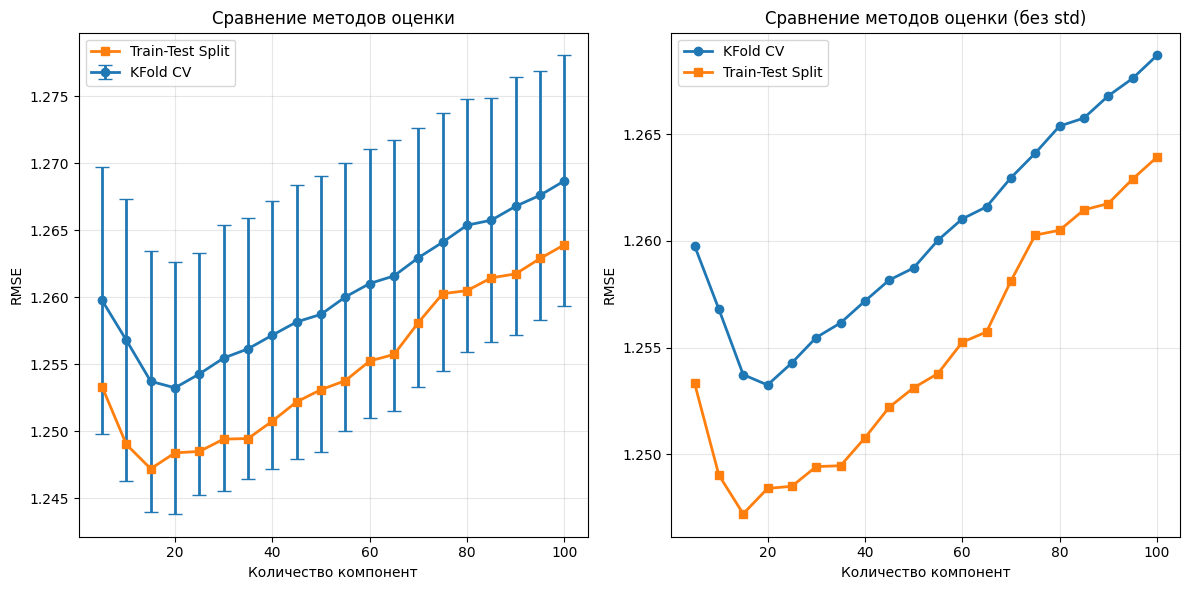

Лучшее количество компонент: 15


In [16]:
from sklearn.model_selection import train_test_split

def evaluate_with_train_test_split(interaction_matrix, n_components_list, test_size=0.2):
    """Оценка параметров с использованием train-test split"""
    results = {}

    # Преобразуем в координатный формат
    coo_matrix = interaction_matrix.tocoo()
    user_indices = coo_matrix.row
    item_indices = coo_matrix.col
    ratings = coo_matrix.data

    # Разделяем данные
    train_idx, test_idx = train_test_split(
        np.arange(len(ratings)),
        test_size=test_size,
        random_state=42
    )

    # Создаем тренировочную матрицу
    train_rows = user_indices[train_idx]
    train_cols = item_indices[train_idx]
    train_data = ratings[train_idx]
    train_matrix = csr_matrix((train_data, (train_rows, train_cols)),
                             shape=interaction_matrix.shape)

    # Создаем тестовые данные
    test_rows = user_indices[test_idx]
    test_cols = item_indices[test_idx]
    test_data = ratings[test_idx]

    for n_components in n_components_list:
        print(f"Оценка для n_components = {n_components}")

        # Обучаем модель
        recommender = SVDRecommender(n_components=n_components)
        recommender.fit(train_matrix)

        # Предсказываем
        predictions = recommender.predict()
        test_predictions = predictions[test_rows, test_cols]

        # Вычисляем RMSE
        rmse = np.sqrt(np.mean((test_data - test_predictions) ** 2))

        results[n_components] = rmse
        print(f"  RMSE = {rmse:.4f}")

    return results

# Сравниваем оба метода
print("Сравнение методов оценки:")
print("=" * 50)

# Train-test split оценка
tts_results = evaluate_with_train_test_split(interaction_matrix, n_components_list)

# Визуализация сравнения
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.errorbar(n_components_list, mean_rmses, yerr=std_rmses,
             marker='o', linewidth=2, capsize=5, label='KFold CV')
plt.plot(n_components_list, [tts_results[n] for n in n_components_list],
         marker='s', linewidth=2, label='Train-Test Split')
plt.xlabel('Количество компонент')
plt.ylabel('RMSE')
plt.title('Сравнение методов оценки')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Без стандартного отклонения для наглядности
plt.plot(n_components_list, mean_rmses, marker='o', linewidth=2, label='KFold CV')
plt.plot(n_components_list, [tts_results[n] for n in n_components_list],
         marker='s', linewidth=2, label='Train-Test Split')
plt.xlabel('Количество компонент')
plt.ylabel('RMSE')
plt.title('Сравнение методов оценки (без std)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Выбираем лучший параметр
best_n_components = n_components_list[np.argmin([tts_results[n] for n in n_components_list])]
print(f"Лучшее количество компонент: {best_n_components}")

In [25]:
# Обучаем финальную модель с лучшими параметрами
final_recommender = SVDRecommender(n_components=best_n_components)
final_recommender.fit(interaction_matrix)
final_predictions = final_recommender.predict()

def get_recommendations(user_id, interaction_matrix, predictions, game_titles, user_to_index, top_n=10):
    """Получение рекомендаций для пользователя"""
    if user_id not in user_to_index:
        print(f"Пользователь {user_id} не найден в датасете")
        return None

    user_idx = user_to_index[user_id]

    # Получаем уже игранные игры
    played_indices = interaction_matrix[user_idx].indices
    played_games = [game_titles[idx] for idx in played_indices]

    # Получаем предсказанные оценки
    user_predictions = predictions[user_idx]

    # Исключаем уже игранные игры
    recommended_indices = []
    recommended_scores = []

    for game_idx, score in enumerate(user_predictions):
        if game_idx not in played_indices and score > 0:
            recommended_indices.append(game_idx)
            recommended_scores.append(score)

    # Сортируем по убыванию оценки
    sorted_indices = np.argsort(recommended_scores)[::-1][:top_n]
    top_recommendations = [
        (game_titles[recommended_indices[i]], recommended_scores[i])
        for i in sorted_indices
    ]

    return played_games, top_recommendations

# Выбираем 5 случайных пользователей
np.random.seed(5)
random_users = np.random.choice(user_ids, 10, replace=False)

print("Рекомендации для случайных пользователей:")
print("=" * 60)

for user in random_users:
    print(f"\n👤 Пользователь: {user}")
    result = get_recommendations(user, interaction_matrix, final_predictions,
                               game_titles, user_to_index, top_n=5)

    if result:
        played_games, recommendations = result

        print("🎮 Уже играл в игры:")
        for i, game in enumerate(played_games[:5]):  # Показываем первые 5
            print(f"   {i+1}. {game}")
        if len(played_games) > 5:
            print(f"   ... и еще {len(played_games) - 5} игр")

        print("\n💡 Рекомендуемые игры:")
        for i, (game, score) in enumerate(recommendations):
            print(f"   {i+1}. {game} (оценка: {score:.4f})")
    print("-" * 50)

Объясненная дисперсия для 15 компонент: 0.2625
Рекомендации для случайных пользователей:

👤 Пользователь: 207590964
🎮 Уже играл в игры:
   1. Ragnarok Online 2

💡 Рекомендуемые игры:
   1. Dota 2 (оценка: 0.0001)
   2. Trine 2 (оценка: 0.0001)
   3. Saints Row The Third (оценка: 0.0001)
   4. Terraria (оценка: 0.0001)
   5. Trine (оценка: 0.0001)
--------------------------------------------------

👤 Пользователь: 147154527
🎮 Уже играл в игры:
   1. Dota 2

💡 Рекомендуемые игры:
   1. Free to Play (оценка: 0.0302)
   2. Nosgoth (оценка: 0.0249)
   3. FreeStyle2 Street Basketball (оценка: 0.0221)
   4. Magicka Wizard Wars (оценка: 0.0202)
   5. SMITE (оценка: 0.0185)
--------------------------------------------------

👤 Пользователь: 76027799
🎮 Уже играл в игры:
   1. Call of Duty Modern Warfare 2 - Multiplayer
   2. Call of Duty Modern Warfare 2
   3. Call of Duty Modern Warfare 3 - Multiplayer
   4. Call of Duty Modern Warfare 3
   5. Company of Heroes (New Steam Version)
   ... и еще 

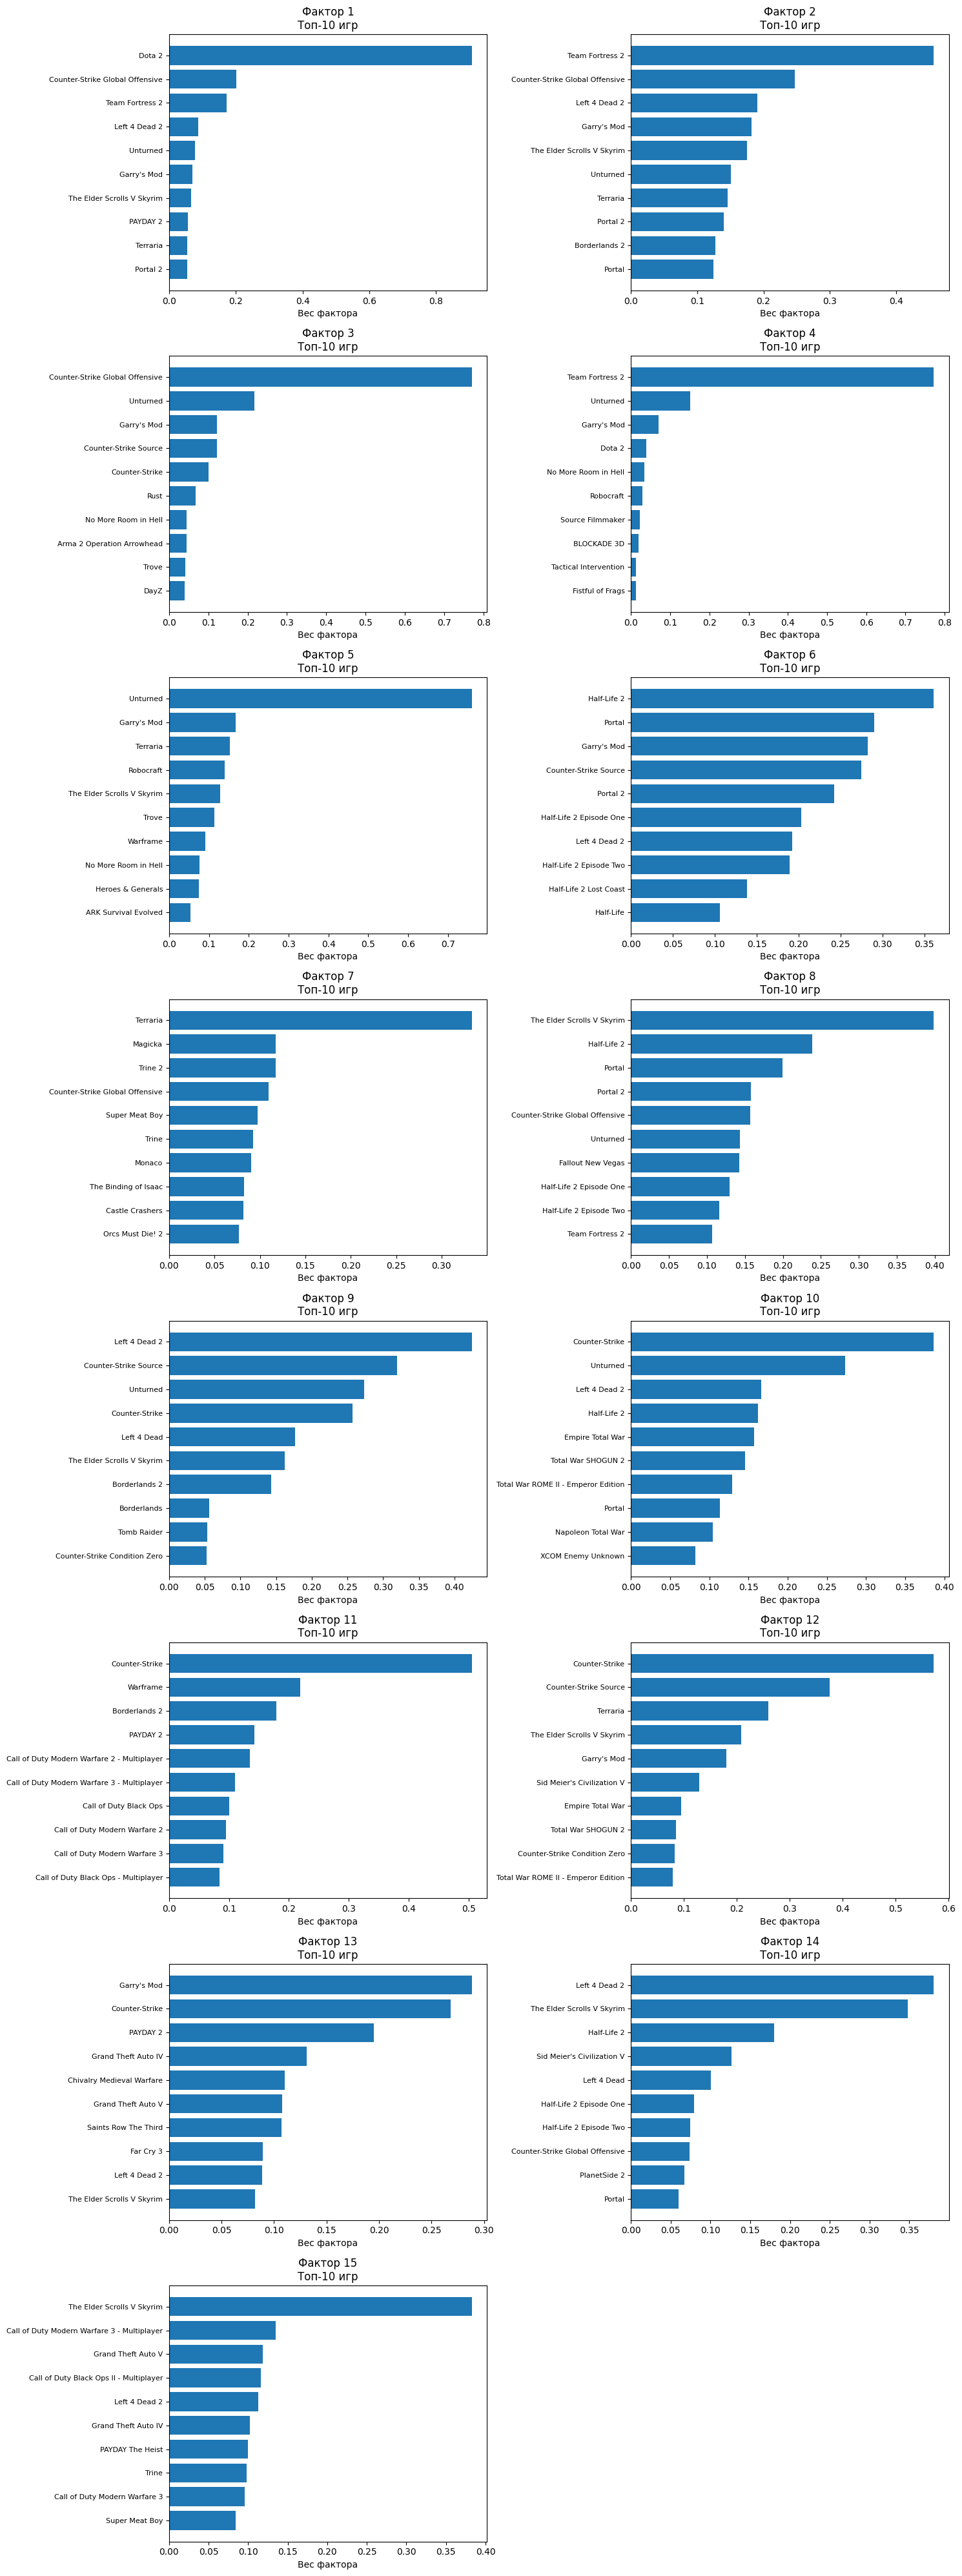

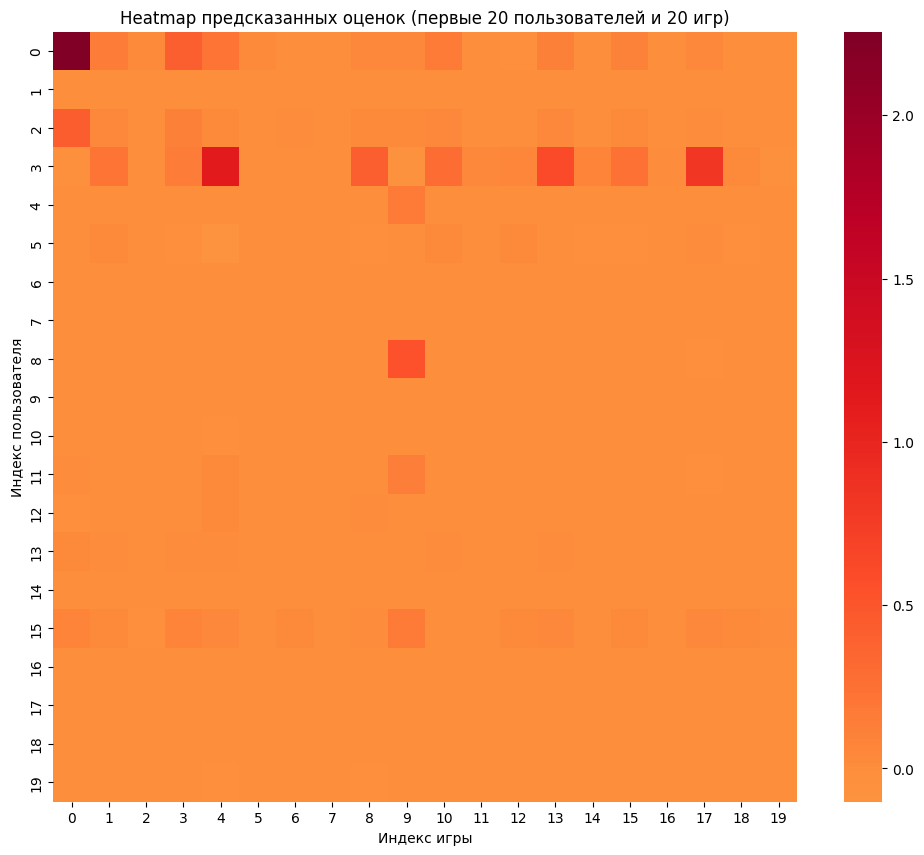

In [24]:
# Анализ латентных факторов игр
def analyze_game_factors(item_factors, game_titles, top_n=10):
    """Анализ самых важных игр в каждом латентном факторе"""
    n_components = item_factors.shape[1]

    plt.figure(figsize=(15, 40))
    for factor_idx in range(n_components):
        plt.subplot(n_components // 2 + 1, 2, factor_idx + 1)

        # Получаем веса для текущего фактора
        factor_weights = item_factors[:, factor_idx]

        # Топ игр с наибольшими весами
        top_indices = np.argsort(factor_weights)[-top_n:]
        top_games = [game_titles[i] for i in top_indices]
        top_weights = [factor_weights[i] for i in top_indices]

        plt.barh(range(len(top_games)), top_weights)
        plt.yticks(range(len(top_games)), top_games, fontsize=8)
        plt.title(f'Фактор {factor_idx + 1}\nТоп-{top_n} игр')
        plt.xlabel('Вес фактора')

    plt.tight_layout()
    plt.show()

# Визуализируем латентные факторы
analyze_game_factors(final_recommender.item_factors, game_titles)

# Дополнительная визуализация: heatmap первых 20x20 пользователей и игр
plt.figure(figsize=(12, 10))
small_prediction = final_predictions[:20, :20]
sns.heatmap(small_prediction, cmap='YlOrRd', center=0)
plt.title('Heatmap предсказанных оценок (первые 20 пользователей и 20 игр)')
plt.xlabel('Индекс игры')
plt.ylabel('Индекс пользователя')
plt.show()